## 01 Data Preparation - MercadoLibre Argentina Sales Analytics

End-to-end ETL for a decoration seller on ML Argentina.  
Data spans Jan 2023 - Apr 2026 across two incompatible source files.

**Sources:**
- CNX_5.xlsx : BigQuery export (Jan 2023 - Apr 2025) | Gross
- Ventas_AR_ML.xlsx : Official ML seller report (Apr 2025 - Apr 2026) | Gross + Net

[CNX has more history but less detail. Ventas_AR_ML has net revenue (after fees) and product titles]


## Setup


In [1]:
import os
import re
import pathlib
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = pathlib.Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PATH_CNX = ROOT / "data" / "raw" / "CNX_5.xlsx"
PATH_ML  = ROOT / "data" / "raw" / "Ventas_AR_ML.xlsx"
PATH_IPC = ROOT / "data" / "ipc_indec.csv"
OUT_PATH = ROOT / "data" / "ventas_clean.csv"

for p in [PATH_CNX, PATH_ML]:
    assert p.exists(), f"Missing raw file: {p}"

print(f"Project root: {ROOT}")
print(f"CNX: {PATH_CNX.name} ({PATH_CNX.stat().st_size / 1024:.0f} KB)")
print(f"ML Official: {PATH_ML.name} ({PATH_ML.stat().st_size / 1024:.0f} KB)")
print("Raw files found.")

Project root: C:\Users\danie\OneDrive\Documents\GIT\mercadolibre-sales-analytics
CNX: CNX_5.xlsx (1121 KB)
ML Official: Ventas_AR_ML.xlsx (33 KB)
Raw files found.


## Domain Constants

In [2]:
# Argentine province ISO 3166-2 codes -> readable names.
# CNX stores provinces as 'AR-B', 'AR-C', etc.
PROV_MAP: dict = {
    "AR-B": "Buenos Aires", "AR-C": "Capital Federal",
    "AR-X": "Córdoba", "AR-S": "Santa Fe",
    "AR-E": "Entre Ríos", "AR-N": "Misiones",
    "AR-Q": "Neuquén", "AR-D": "San Luis",
    "AR-M": "Mendoza", "AR-U": "Chubut",
    "AR-W": "Corrientes", "AR-P": "Formosa",
    "AR-T": "Tucumán", "AR-K": "Catamarca",
    "AR-J": "San Juan", "AR-A": "Salta",
    "AR-G": "Santiago del Estero",
}

# Spanish month names -> month numbers
# ML Official exports dates as "1 de abril de 2026 12:09 hs.", needs custom parser.
MESES_ES: dict = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12,
}

# Items confirmed as off-topic after manual review of the raw data.
# Excluded here to keep the clean dataset focused on decoration sales.
# A single Gucci perfume sale (~$200K ARS) distorted the gross margin by 9pp.
ITEMS_OFF_TOPIC: list = [
    1636648857, # Gucci perfume: confirmed by product title
    1699566940, # $149,000 ARS: no title, discontinued listing
    1699553874, # $25,900  ARS: no title, discontinued listing
    1381829061, # $20,000  ARS: no title (Sep 2023)
    1381899765, # $20,000  ARS: no title, same batch as above
    1423780045, # $19,493  ARS: no title, discontinued listing
    1699402488, # $15,000  ARS: no title, discontinued listing
]

# Unified column schema for both sources (used after merge).
FINAL_COLS: list = [
    "order_id", "date", "unit_price", "quantity",
    "gross_revenue", "net_revenue",
    "product_title", "item_id",
    "province", "city", "source",
]

print(f"Province mappings: {len(PROV_MAP)}")
print(f"Off-topic item IDs: {len(ITEMS_OFF_TOPIC)}")

Province mappings: 17
Off-topic item IDs: 7


## Inspectation Raw Files

In [3]:
# CNX: inspect without any header assumptions
raw_cnx = pd.read_excel(PATH_CNX, sheet_name="Respuesta - Reporte Ventas", header=None)
print(f"CNX raw shape: {raw_cnx.shape}")
print("First 8 rows: rows 0-5 are metadata, row 6+ is data:")
raw_cnx.head(8).drop(columns=[1])  # column 1 = buyer alias (omitted for privacy)

CNX raw shape: (311, 10)
First 8 rows: rows 0-5 are metadata, row 6+ is data:


,0,2,3,4,5,6,7,8,9
0,User ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fecha Inicio,Año-Mes-Dia,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fecha Fin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Seller,Fecha,Order_id,Item_id,Monto,Cantidad,Provincia,Ciudad,MODE
6,129626527,2023-01-06 00:00:00,2000004886252378,867078087,999,1,AR-C,Villa Urquiza,NaN
7,129626527,2023-01-06 00:00:00,2000004882039612,1164456488,799,1,AR-C,Almagro,NaN


In [4]:
# ML Official: inspect without assumptions
raw_ml = pd.read_excel(PATH_ML, sheet_name="Ventas AR", header=None)
print(f"ML Official raw shape: {raw_ml.shape}")
print(f"Total columns: {raw_ml.shape[1]}")
print("First 8 rows (showing first 12 cols):")
raw_ml.head(8).iloc[:, :12]

ML Official raw shape: (71, 63)
Total columns: 63
First 8 rows (showing first 12 cols):


,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,En este reporte encontrarás la información de ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,Ir a Facturas y reportes de tus cargos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ventas Estado de tus ventas al 6 de abril de ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ventas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# de venta,Fecha de venta,Estado,Descripción del estado,Paquete de varios productos,Pertenece a un kit,Unidades,Ingresos por productos (ARS),Cargo por venta,Costo fijo,Costo por ofrecer cuotas,Ingresos por envío (ARS)
6,2000015793619604,1 de abril de 2026 12:09 hs.,Esperando disponibilidad de stock,Te entregaremos la etiqueta de envío el 8 de a...,No,No,1,18999,-2754.86,-2465,NaN,7240
7,2000015650108664,21 de marzo de 2026 21:14 hs.,Entregado,Podrás usar este dinero a partir del 22 de abril.,No,No,1,18999,-2849.85,-2500,NaN,NaN


## Clean CNX 

In [5]:
def load_cnx(path) -> pd.DataFrame:
    """ Load and clean the CNX BigQuery export. """
  
    raw = pd.read_excel(path, sheet_name="Respuesta - Reporte Ventas", header=None)
    assert len(raw) > 10, f"CNX file too short: {len(raw)} rows"

    df = raw.iloc[6:].copy().reset_index(drop=True)
    df.columns = [
        "seller", "buyer_alias", "date_raw", "order_id",
        "item_id", "unit_price", "quantity", "province_code", "city", "mode"
    ]

    # Cast types, errors='coerce' turns bad values into NaN instead of crashing
    df["date"] = pd.to_datetime(df["date_raw"], errors="coerce")
    df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").fillna(1)
    df["item_id"] = pd.to_numeric(df["item_id"], errors="coerce").astype("Int64")
    df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce")

    # Drop rows with no date or price
    n_before = len(df)
    df = df.dropna(subset=["date", "unit_price"]).reset_index(drop=True)
    dropped = n_before - len(df)
    if dropped > 0:
        print(f"[CNX] {dropped} rows dropped")

    # Derived columns
    df["gross_revenue"] = df["unit_price"] * df["quantity"]
    df["net_revenue"] = np.nan   # not available in CNX
    df["product_title"] = np.nan   # not available in CNX
    df["province"] = df["province_code"].map(PROV_MAP)
    df["source"] = "CNX"

    # Assertions, catch data problems before they reach downstream analysis
    assert len(df) > 0, "CNX is empty after cleaning"
    assert df["unit_price"].min() > 0, "CNX has negative or zero unit prices"
    assert df["date"].isna().sum() == 0, "CNX has null dates after cleaning"

    return df

df_cnx = load_cnx(PATH_CNX)
print(f"CNX loaded: {len(df_cnx):,} orders")
print(f"Date range: {df_cnx['date'].min().date()} → {df_cnx['date'].max().date()}")
print(f"Gross revenue: ${df_cnx['gross_revenue'].sum():,.0f} ARS")
df_cnx[["order_id","date","unit_price","quantity","gross_revenue","province","source"]].head(3)

CNX loaded: 305 orders
Date range: 2023-01-06 → 2025-04-30
Gross revenue: $1,256,306 ARS


,order_id,date,unit_price,quantity,gross_revenue,province,source
0,2000004886252378,2023-01-06,999.0,1,999.0,Capital Federal,CNX
1,2000004882039612,2023-01-06,799.0,1,799.0,Capital Federal,CNX
2,2000004889340356,2023-01-07,1099.0,1,1099.0,Buenos Aires,CNX


## Clean Ventas_AR_ML

**Spanish Date Parser**

In [6]:
def parse_spanish_date(text: str) -> pd.Timestamp:
    """ Convert Spanish-format date string to pandas Timestamp. """

    if not isinstance(text, str):
        return pd.NaT
    match = re.search(r"(\d+) de (\w+) de (\d{4})", text.lower())
    if match:
        day = int(match.group(1))
        month_str = match.group(2)
        year = int(match.group(3))
        month = MESES_ES.get(month_str, 0)
        if month:
            return pd.Timestamp(year, month, day)
    return pd.NaT

# Smoke tests
assert parse_spanish_date("1 de abril de 2026 12:09 hs.") == pd.Timestamp("2026-04-01")
assert pd.isna(parse_spanish_date("invalid"))
assert pd.isna(parse_spanish_date(None))
print("parse_spanish_date - all assertions passed")

parse_spanish_date - all assertions passed


**Load and Clean ML**

In [7]:
def load_ml_oficial(path) -> pd.DataFrame:
    """ Load and clean the official MercadoLibre seller report. """

    raw = pd.read_excel(path, sheet_name="Ventas AR", header=None)
    assert len(raw) > 10, f"ML Official file is too short: {len(raw)} rows"

    df = raw.iloc[6:].copy().reset_index(drop=True)
    df.columns = range(len(df.columns))

    out = pd.DataFrame()
    out["date"] = df[1].apply(parse_spanish_date)
    out["order_id"] = pd.to_numeric(df[0],  errors="coerce")
    out["status"] = df[2].astype(str)
    out["quantity"] = pd.to_numeric(df[6],  errors="coerce").fillna(1)
    out["gross_revenue"] = pd.to_numeric(df[7],  errors="coerce")
    out["net_revenue"] = pd.to_numeric(df[18], errors="coerce")
    out["unit_price"] = pd.to_numeric(df[26], errors="coerce")
    out["item_id"] = (
        pd.to_numeric(
            df[22].astype(str).str.replace("MLA", "", regex=False),
            errors="coerce"
        ).astype("Int64")
    )
    out["product_title"] = df[24].astype(str).str.strip()
    out["city"] = df[36].astype(str).replace({"nan": np.nan})
    out["province"] = df[37].astype(str).replace({"nan": np.nan})
    out["source"] = "ML_Oficial"

    # Drop nulls and multi-product bundle rows (no item-level price breakdown available)
    n_before = len(out)
    out = out.dropna(subset=["date", "gross_revenue"])
    out = out[out["status"] != "Paquete de 3 productos"].reset_index(drop=True)
    dropped = n_before - len(out)
    if dropped > 0:
        print(f"  [ML] {dropped} rows dropped")

    assert len(out) > 0,                   "ML Official is empty after cleaning"
    assert out["gross_revenue"].min() > 0, "ML Official has negative gross revenue"

    return out


df_ml = load_ml_oficial(PATH_ML)
print(f"ML Official loaded: {len(df_ml):,} orders")
print(f"Date range: {df_ml['date'].min().date()} → {df_ml['date'].max().date()}")
print(f"Net revenue rows: {df_ml['net_revenue'].notna().sum():,}")
df_ml[["order_id","date","unit_price","gross_revenue","net_revenue","product_title","province"]].head(3)

  [ML] 4 rows dropped
ML Official loaded: 61 orders
Date range: 2025-04-09 → 2026-04-01
Net revenue rows: 61


,order_id,date,unit_price,gross_revenue,net_revenue,product_title,province
0,2000015793619604,2026-04-01,18999.0,18999.0,13779.14,Figuras Bichikids En Goma Eva X 7,Buenos Aires
1,2000015650108664,2026-03-21,18999.0,18999.0,13649.15,Cartel Para Decoración De Snoopy En Goma Eva,
2,2000011998216421,2026-03-12,200000.0,200000.0,162530.00,Perfume Gucci Guilty Pour Homme 90 Ml Floriental,Capital Federal


## Exclude Off-Topic Items

In [8]:
def exclude_off_topic(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Remove known off-topic item IDs and report the revenue impact."""

    mask = df["item_id"].isin(ITEMS_OFF_TOPIC)
    n_excluded = mask.sum()
    revenue_removed = df.loc[mask, "gross_revenue"].sum()
    pct = revenue_removed / df["gross_revenue"].sum() * 100

    if n_excluded > 0:
        print(f"[{label}] Excluded {n_excluded} off-topic sales")
        print(f"[{label}] Revenue removed: ${revenue_removed:,.0f} ARS ({pct:.1f}% of gross)")
    else:
        print(f"[{label}] No off-topic items found")

    return df[~mask].copy().reset_index(drop=True)

df_cnx = exclude_off_topic(df_cnx, "CNX")
df_ml  = exclude_off_topic(df_ml,  "ML")

[CNX] Excluded 6 off-topic sales
[CNX] Revenue removed: $249,393 ARS (19.9% of gross)
[ML] Excluded 1 off-topic sales
[ML] Revenue removed: $200,000 ARS (23.6% of gross)


## Merge Sources

In [9]:
CUTOFF = pd.Timestamp("2025-04-01")

cnx_pre = df_cnx[df_cnx["date"] < CUTOFF][FINAL_COLS].copy()
ml_post = df_ml[ df_ml["date"] >= CUTOFF][FINAL_COLS].copy()

df = pd.concat([cnx_pre, ml_post], ignore_index=True)
df = df.sort_values("date").reset_index(drop=True)

print(f"Final dataset: {len(df):,} orders")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Source split: {df['source'].value_counts().to_dict()}")
df.head(3)

Final dataset: 353 orders
Date range: 2023-01-06 → 2026-04-01
Source split: {'CNX': 293, 'ML_Oficial': 60}


,order_id,date,unit_price,quantity,gross_revenue,net_revenue,product_title,item_id,province,city,source
0,2000004886252378,2023-01-06,999.0,1.0,999.0,NaN,NaN,867078087,Capital Federal,Villa Urquiza,CNX
1,2000004882039612,2023-01-06,799.0,1.0,799.0,NaN,NaN,1164456488,Capital Federal,Almagro,CNX
2,2000004889340356,2023-01-07,1099.0,1.0,1099.0,NaN,NaN,1224328728,Buenos Aires,NaN,CNX


## Feature Engineering

In [10]:
# Time features for grouping and seasonality analysis
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek    
df["is_weekend"] = df["day_of_week"] >= 5
df["year_month"] = df["date"].dt.to_period("M")

# Revenue per unit 
df["revenue_per_unit"] = df["gross_revenue"] / df["quantity"].clip(lower=1)

# ML fee estimate 
df["ml_fee_pct"] = np.where(
    df["net_revenue"].notna() & (df["gross_revenue"] > 0),
    (1 - df["net_revenue"] / df["gross_revenue"]) * 100,
    np.nan
)

print("Features added: year, month, quarter, day_of_week, is_weekend, year_month, revenue_per_unit, ml_fee_pct")
print("\nML fee %:")
print(df["ml_fee_pct"].describe().round(1).to_string())

Features added: year, month, quarter, day_of_week, is_weekend, year_month, revenue_per_unit, ml_fee_pct

ML fee %:
count     60.0
mean      40.8
std       25.0
min       21.7
25%       26.7
50%       28.9
75%       46.6
max      100.0


## Inflation Adjustment (ipc_indec)

In [11]:
try:
    ipc = pd.read_csv(PATH_IPC)
    ipc.columns = ipc.columns.str.lower().str.strip()

    date_col = next(c for c in ipc.columns if "fecha" in c or "date" in c)
    idx_col  = next(c for c in ipc.columns if "cpi" in c or "ipc" in c or "index" in c)

    ipc["year_month"] = pd.to_datetime(ipc[date_col], errors="coerce").dt.to_period("M")
    ipc = ipc.rename(columns={idx_col: "cpi_index"})[["year_month", "cpi_index"]]

    df = df.merge(ipc, on="year_month", how="left")

    base_cpi = df.loc[df["cpi_index"].notna(), "cpi_index"].iloc[0]
    df["gross_revenue_real"] = df["gross_revenue"] / df["cpi_index"] * base_cpi
    df["unit_price_real"]    = df["unit_price"]    / df["cpi_index"] * base_cpi

    n_null = df["cpi_index"].isna().sum()
    print(f"IPC loaded: {len(ipc)} monthly observations")
    print(f"Base CPI: {base_cpi:.1f} (= {df['date'].min().strftime('%b %Y')})")
    if n_null > 0:
        print(f"Rows without IPC: {n_null}")

except (FileNotFoundError, StopIteration):
    print("ipc_indec.csv not found - skipping inflation adjustment")
    df["cpi_index"] = np.nan
    df["gross_revenue_real"] = np.nan
    df["unit_price_real"] = np.nan

IPC loaded: 39 monthly observations
Base CPI: 100.0 (= Jan 2023)
Rows without IPC: 1


## Data Quality Validation

In [12]:
checks = {
    "No null dates" : df["date"].isna().sum() == 0,
    "No zero/negative prices" : (df["unit_price"].fillna(1) > 0).all(),
    "No negative gross revenue" : (df["gross_revenue"] > 0).all(),
    "Both sources present" : df["source"].nunique() == 2,
    "Date range plausible" : (df["date"].min().year >= 2023) and (df["date"].max().year <= 2027),
    "No duplicate order IDs" : df["order_id"].duplicated().sum() == 0,
    "Cutoff respected (CNX end)" : df.loc[df["source"] == "CNX", "date"].max() < CUTOFF,
    "Cutoff respected (ML start)": df.loc[df["source"] == "ML_Oficial", "date"].min() >= CUTOFF,
}

all_passed = True
for check, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"{status}  {check}")
    if not passed:
        all_passed = False

result = "All checks passed." if all_passed else "Some checks FAILED"
print(f"\n{result}")

# Null coverage report
print("\nNull % by column (expected nulls noted):")
null_pct = (df.isna().sum() / len(df) * 100).round(1).sort_values(ascending=False)
for col, pct in null_pct[null_pct > 0].items():
    note = " - expected (not available in CNX)" if col in ["net_revenue", "product_title"] else ""
    print(f"{col:<28} {pct:.1f}%{note}")

PASS  No null dates
PASS  No zero/negative prices
PASS  No negative gross revenue
PASS  Both sources present
PASS  Date range plausible
PASS  No duplicate order IDs
PASS  Cutoff respected (CNX end)
PASS  Cutoff respected (ML start)

All checks passed.

Null % by column (expected nulls noted):
net_revenue                  83.0% - expected (not available in CNX)
product_title                83.0% - expected (not available in CNX)
ml_fee_pct                   83.0%
city                         21.2%
province                     9.9%
gross_revenue_real           0.3%
unit_price_real              0.3%
cpi_index                    0.3%


## Exploratory Analysis

**Dataset Overview**

In [13]:
print("-DATASET OVERVIEW-")
print()
print(f"Total orders: {len(df):,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique items: {df['item_id'].nunique()}")
print(f"Unique provinces: {df['province'].nunique()}")
print()
print(f"Gross revenue total: ${df['gross_revenue'].sum():,.0f} ARS")
print(f"Avg ticket (mean): ${df['unit_price'].mean():,.0f} ARS")
print(f"Avg ticket (median): ${df['unit_price'].median():,.0f} ARS")
print(f"Max single ticket: ${df['unit_price'].max():,.0f} ARS")
print()
print("Orders by source:")
print(df["source"].value_counts().to_string())

-DATASET OVERVIEW-

Total orders: 353
Date range: 2023-01-06 → 2026-04-01
Unique items: 120
Unique provinces: 13

Gross revenue total: $1,564,450 ARS
Avg ticket (mean): $4,379 ARS
Avg ticket (median): $2,890 ARS
Max single ticket: $29,000 ARS

Orders by source:
source
CNX           293
ML_Oficial     60


**Monthly Revenue Trend**

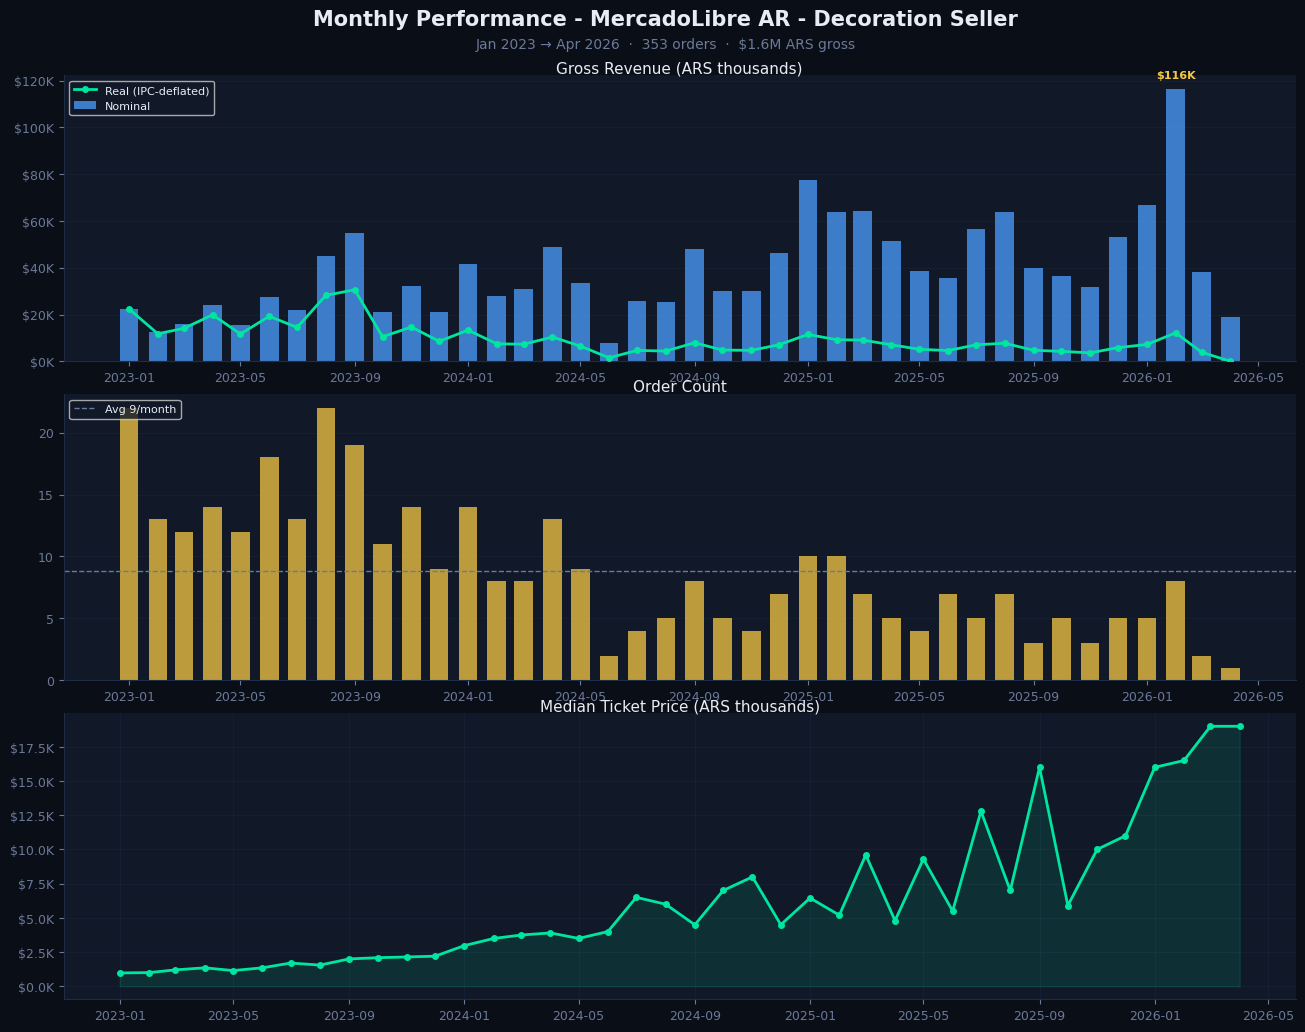

In [14]:
monthly = (
    df.groupby("year_month")
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        orders=("order_id", "count"),
        median_ticket=("unit_price", "median"),
    )
    .reset_index()
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()

if df["gross_revenue_real"].notna().any():
    real = df.groupby("year_month")["gross_revenue_real"].sum().reset_index()
    monthly = monthly.merge(real, on="year_month", how="left")

C = dict(
    bg="#0A0E17", surface="#111827", surf2="#1A2235", border="#1E2D45",
    accent="#00E5A0", gold="#F5C842", red="#FF4D6A", blue="#4D9FFF",
    text="#E8EDF5", muted="#6B7A99",
)

import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["surface"],
    "axes.edgecolor": C["border"], "axes.labelcolor": C["muted"],
    "axes.titlecolor": C["text"], "text.color": C["text"],
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": C["border"], "grid.linewidth": 0.6,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "font.family": "DejaVu Sans",
})

fig = plt.figure(figsize=(14, 11), facecolor=C["bg"])
fig.text(0.5, 0.98, "Monthly Performance - MercadoLibre AR - Decoration Seller",
         ha="center", va="top", fontsize=15, fontweight="bold", color=C["text"])
fig.text(0.5, 0.955, f"{df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}  ·  {len(df):,} orders  ·  ${df['gross_revenue'].sum()/1e6:.1f}M ARS gross",
         ha="center", va="top", fontsize=10, color=C["muted"])

ax1 = fig.add_axes([0.07, 0.66, 0.88, 0.26])
ax2 = fig.add_axes([0.07, 0.37, 0.88, 0.26])
ax3 = fig.add_axes([0.07, 0.08, 0.88, 0.26])

# Panel 1: Revenue bars + real overlay
bar_w = 20
bars = ax1.bar(monthly["date"], monthly["gross_revenue"] / 1e3, width=bar_w,
               color=C["blue"], alpha=0.75, zorder=2, label="Nominal")
if "gross_revenue_real" in monthly.columns:
    ax1.plot(monthly["date"], monthly["gross_revenue_real"] / 1e3,
             color=C["accent"], linewidth=2, marker="o", markersize=4,
             zorder=3, label="Real (IPC-deflated)")

max_idx = monthly["gross_revenue"].idxmax()
ax1.annotate(
    f"${monthly.loc[max_idx, 'gross_revenue']/1e3:.0f}K",
    xy=(monthly.loc[max_idx, "date"], monthly.loc[max_idx, "gross_revenue"] / 1e3),
    xytext=(0, 8), textcoords="offset points",
    ha="center", fontsize=8, color=C["gold"], fontweight="bold"
)
ax1.set_title("Gross Revenue (ARS thousands)", fontsize=11, color=C["text"], pad=-20)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(axis="y", alpha=0.4, zorder=0)
ax1.set_facecolor(C["surface"])
for sp in ["top","right"]:
    ax1.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax1.spines[sp].set_color(C["border"])

# Panel 2: Orders
ax2.bar(monthly["date"], monthly["orders"], width=bar_w,
        color=C["gold"], alpha=0.75, zorder=2)
avg_orders = monthly["orders"].mean()
ax2.axhline(avg_orders, color=C["muted"], linewidth=1, linestyle="--",
            label=f"Avg {avg_orders:.0f}/month")
ax2.set_title("Order Count", fontsize=11, color=C["text"], pad=-20)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(axis="y", alpha=0.4, zorder=0)
ax2.set_facecolor(C["surface"])
for sp in ["top","right"]:
    ax2.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax2.spines[sp].set_color(C["border"])

# Panel 3: Median ticket
ax3.plot(monthly["date"], monthly["median_ticket"] / 1e3,
         color=C["accent"], linewidth=2, marker="o", markersize=4, zorder=3)
ax3.fill_between(monthly["date"], monthly["median_ticket"] / 1e3,
                 alpha=0.12, color=C["accent"], zorder=2)
ax3.set_title("Median Ticket Price (ARS thousands)", fontsize=11, color=C["text"], pad=-20)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}K"))
ax3.grid(alpha=0.4, zorder=0)
ax3.set_facecolor(C["surface"])
for sp in ["top","right"]:
    ax3.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax3.spines[sp].set_color(C["border"])

os.makedirs(ROOT / "plots", exist_ok=True)
plt.savefig(ROOT / "plots" / "01_monthly_overview.png", dpi=150, bbox_inches="tight",
            facecolor=C["bg"])
plt.show()


**Seasonality**

Peak months: ['Dec', 'Feb']


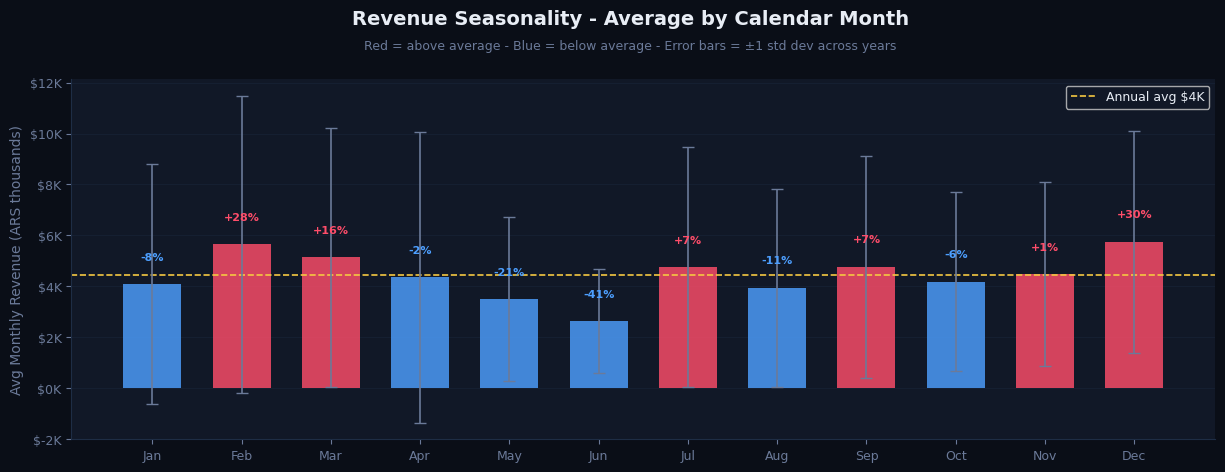

In [15]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

by_month = df.groupby("month")["gross_revenue"].agg(["mean","std"]).reset_index()
by_month["month_name"] = by_month["month"].apply(lambda m: MONTH_NAMES[m-1])
overall_mean = by_month["mean"].mean()
by_month["vs_avg"] = (by_month["mean"] / overall_mean - 1) * 100 

fig = plt.figure(figsize=(13, 5), facecolor=C["bg"])
fig.text(0.5, 0.98, "Revenue Seasonality - Average by Calendar Month",
         ha="center", va="top", fontsize=14, fontweight="bold", color=C["text"])
fig.text(0.5, 0.92, "Red = above average - Blue = below average - Error bars = ±1 std dev across years",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax = fig.add_axes([0.07, 0.12, 0.88, 0.72])

bar_colors = [C["red"] if v >= 0 else C["blue"] for v in by_month["vs_avg"]]
bars = ax.bar(by_month["month_name"], by_month["mean"] / 1e3,
              color=bar_colors, alpha=0.82, zorder=2, width=0.65)
ax.errorbar(by_month["month_name"], by_month["mean"] / 1e3,
            yerr=by_month["std"] / 1e3,
            fmt="none", color=C["muted"], capsize=4, linewidth=1.2, zorder=3)

ax.axhline(overall_mean / 1e3, color=C["gold"], linewidth=1.2,
           linestyle="--", zorder=2, label=f"Annual avg ${overall_mean/1e3:.0f}K")

for bar, (_, row) in zip(bars, by_month.iterrows()):
    sign = "+" if row["vs_avg"] >= 0 else ""
    color = C["red"] if row["vs_avg"] >= 0 else C["blue"]
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (by_month["std"].max()/1e3 * 0.15),
            f"{sign}{row['vs_avg']:.0f}%",
            ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

ax.set_ylabel("Avg Monthly Revenue (ARS thousands)", color=C["muted"], fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.set_facecolor(C["surface"])
ax.grid(axis="y", alpha=0.4, zorder=0)
ax.legend(fontsize=9)
for sp in ["top","right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax.spines[sp].set_color(C["border"])

peak_months = by_month.nlargest(2, "mean")["month_name"].tolist()
print(f"Peak months: {peak_months}")

plt.savefig(ROOT / "plots" / "02_seasonality.png", dpi=150, bbox_inches="tight", facecolor=C["bg"])
plt.show()


**Geographic Distribution**

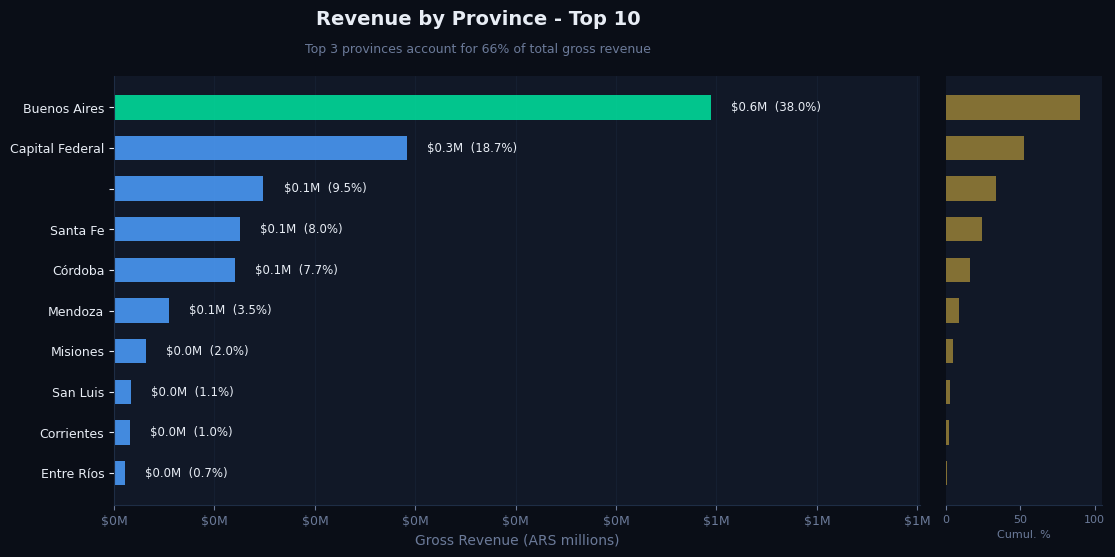

In [16]:
top_prov = (
    df.groupby("province")["gross_revenue"]
    .sum()
    .sort_values(ascending=True)   
    .tail(10)
    .reset_index()
)
top_prov["share_pct"] = top_prov["gross_revenue"] / df["gross_revenue"].sum() * 100
top_prov["cum_pct"] = top_prov["share_pct"].cumsum()

fig = plt.figure(figsize=(13, 5.5), facecolor=C["bg"])
fig.text(0.5, 0.98, "Revenue by Province - Top 10",
         ha="center", va="top", fontsize=14, fontweight="bold", color=C["text"])
pct_top3 = top_prov.tail(3)["share_pct"].sum()
fig.text(0.5, 0.92, f"Top 3 provinces account for {pct_top3:.0f}% of total gross revenue",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax = fig.add_axes([0.22, 0.08, 0.62, 0.78])
ax2 = fig.add_axes([0.86, 0.08, 0.12, 0.78])   

n = len(top_prov)
bar_colors = [C["blue"]] * (n - 1) + [C["accent"]]
alphas = [0.5 + 0.5 * (i / (n-1)) for i in range(n)]

bars = ax.barh(top_prov["province"], top_prov["gross_revenue"] / 1e6,
               color=bar_colors, alpha=0.85, height=0.6, zorder=2)

for bar, (_, row) in zip(bars, top_prov.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
            f"${w:.1f}M  ({row['share_pct']:.1f}%)",
            va="center", fontsize=8.5, color=C["text"])

ax.set_xlabel("Gross Revenue (ARS millions)", color=C["muted"], fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.set_facecolor(C["surface"])
ax.grid(axis="x", alpha=0.4, zorder=0)
for sp in ["top","right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax.spines[sp].set_color(C["border"])
ax.tick_params(axis="y", colors=C["text"], labelsize=9)
ax.set_xlim(0, top_prov["gross_revenue"].max() / 1e6 * 1.35)

ax2.barh(top_prov["province"], top_prov["cum_pct"],
         color=C["gold"], alpha=0.5, height=0.6)
ax2.set_xlim(0, 105)
ax2.set_xlabel("Cumul. %", color=C["muted"], fontsize=8)
ax2.set_facecolor(C["surface"])
ax2.set_yticks([])
for sp in ["top","right","left"]:
    ax2.spines[sp].set_visible(False)
ax2.spines["bottom"].set_color(C["border"])
ax2.tick_params(colors=C["muted"], labelsize=8)

plt.savefig(ROOT / "plots" / "03_provinces.png", dpi=150, bbox_inches="tight", facecolor=C["bg"])
plt.show()


**Ticket Price Distribution**

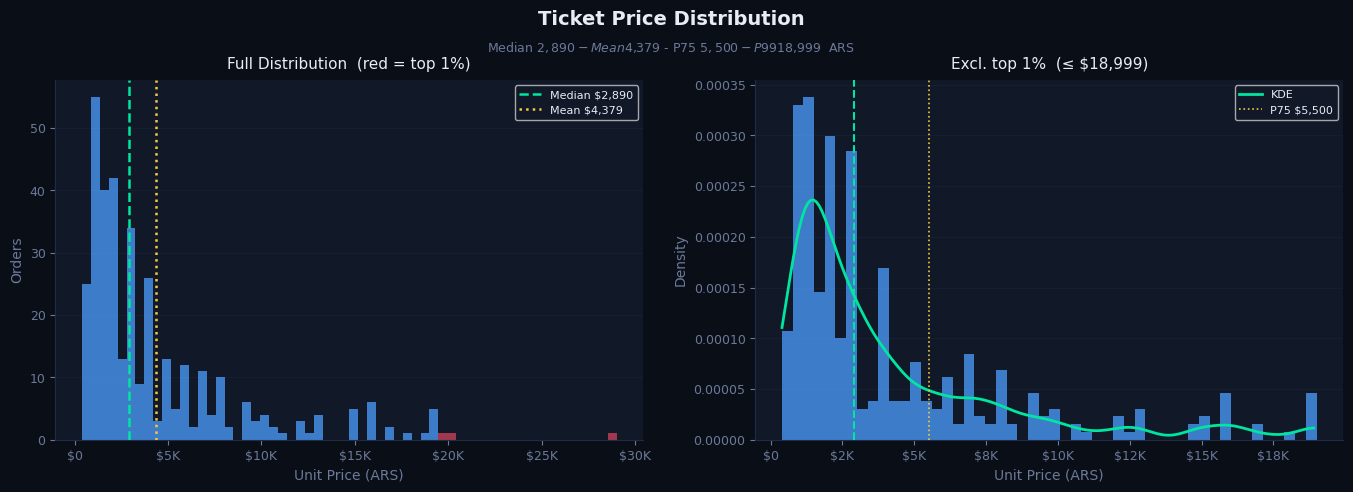

In [17]:
p99  = df["unit_price"].quantile(0.99)
p75  = df["unit_price"].quantile(0.75)
med  = df["unit_price"].median()
mean = df["unit_price"].mean()

fig = plt.figure(figsize=(14, 5), facecolor=C["bg"])
fig.text(0.5, 0.98, "Ticket Price Distribution",
         ha="center", va="top", fontsize=14, fontweight="bold", color=C["text"])
fig.text(0.5, 0.92,
         f"Median ${med:,.0f} - Mean ${mean:,.0f} - P75 ${p75:,.0f} - P99 ${p99:,.0f}  ARS",
         ha="center", va="top", fontsize=9, color=C["muted"])

ax1 = fig.add_axes([0.06, 0.12, 0.42, 0.72])
ax2 = fig.add_axes([0.56, 0.12, 0.42, 0.72])

n1, bins1, patches1 = ax1.hist(df["unit_price"], bins=60,
                                color=C["blue"], alpha=0.75, edgecolor="none", zorder=2)

for patch, left_edge in zip(patches1, bins1[:
    -1]):
    if left_edge >= p99:
        patch.set_facecolor(C["red"])
        patch.set_alpha(0.6)

ax1.axvline(med,  color=C["accent"], linewidth=1.8, linestyle="--",
            label=f"Median ${med:,.0f}", zorder=3)
ax1.axvline(mean, color=C["gold"], linewidth=1.8, linestyle=":",
            label=f"Mean ${mean:,.0f}", zorder=3)
ax1.set_title("Full Distribution  (red = top 1%)", fontsize=11, color=C["text"], pad=8)
ax1.set_xlabel("Unit Price (ARS)", color=C["muted"])
ax1.set_ylabel("Orders", color=C["muted"])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K" if x >= 1000 else f"${x:.0f}"))
ax1.legend(fontsize=8)
ax1.set_facecolor(C["surface"])
ax1.grid(axis="y", alpha=0.4, zorder=0)
for sp in ["top","right"]:
    ax1.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax1.spines[sp].set_color(C["border"])

df_clip = df[df["unit_price"] <= p99]["unit_price"]
n2, bins2, _ = ax2.hist(df_clip, bins=50, color=C["blue"], alpha=0.75,
                         edgecolor="none", zorder=2, density=True)

from scipy.stats import gaussian_kde
kde = gaussian_kde(df_clip, bw_method=0.15)
x_range = range(int(df_clip.min()), int(df_clip.max()), 100)
x_kde = list(x_range)
ax2.plot(x_kde, kde(x_kde), color=C["accent"], linewidth=2, zorder=3, label="KDE")
ax2.axvline(med, color=C["accent"], linewidth=1.5, linestyle="--", zorder=3)
ax2.axvline(p75, color=C["gold"], linewidth=1.2, linestyle=":",
            label=f"P75 ${p75:,.0f}", zorder=3)
ax2.set_title(f"Excl. top 1%  (≤ ${p99:,.0f})", fontsize=11, color=C["text"], pad=8)
ax2.set_xlabel("Unit Price (ARS)", color=C["muted"])
ax2.set_ylabel("Density", color=C["muted"])
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K" if x >= 1000 else f"${x:.0f}"))
ax2.legend(fontsize=8)
ax2.set_facecolor(C["surface"])
ax2.grid(axis="y", alpha=0.4, zorder=0)
for sp in ["top","right"]:
    ax2.spines[sp].set_visible(False)
for sp in ["left","bottom"]:
    ax2.spines[sp].set_color(C["border"])

plt.savefig(ROOT / "plots" / "04_ticket_distribution.png", dpi=150, bbox_inches="tight", facecolor=C["bg"])
plt.show()


## Export Clean Dataset

In [18]:
df.to_csv(OUT_PATH, index=False)

print(f"Clean dataset saved: {OUT_PATH}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("Next:")
print("  02_eda.ipynb - deeper exploratory analysis")
print("  03_rfm_segmentation - customer segmentation")
print("  04_demand_forecasting - time series forecasting")
print("  05_price_elasticity - pricing sensitivity")
print("  06_ab_testing - experiment analysis")
print("  07_cohort_analysis - retention & LTV")

Clean dataset saved: C:\Users\danie\OneDrive\Documents\GIT\mercadolibre-sales-analytics\data\ventas_clean.csv
Shape: (353, 22)
Columns: ['order_id', 'date', 'unit_price', 'quantity', 'gross_revenue', 'net_revenue', 'product_title', 'item_id', 'province', 'city', 'source', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'year_month', 'revenue_per_unit', 'ml_fee_pct', 'cpi_index', 'gross_revenue_real', 'unit_price_real']

Next:
  02_eda.ipynb - deeper exploratory analysis
  03_rfm_segmentation - customer segmentation
  04_demand_forecasting - time series forecasting
  05_price_elasticity - pricing sensitivity
  06_ab_testing - experiment analysis
  07_cohort_analysis - retention & LTV
